In [1]:
import pandas as pd
titanic = pd.read_csv('titanic.csv')
titanic['Age'] = titanic.groupby('Pclass')['Age'].transform(lambda x: x.fillna(x.median()))

In [2]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
titanic['Sex_encoded'] = le.fit_transform(titanic['Sex'])
print(titanic[['Sex', 'Sex_encoded']].head())

titanic_encoded = pd.get_dummies(titanic, columns=['Embarked'], prefix='Embarked')
print(titanic_encoded.filter(like='Embarked').head())

      Sex  Sex_encoded
0    male            1
1  female            0
2  female            0
3  female            0
4    male            1
   Embarked_C  Embarked_Q  Embarked_S
0       False       False        True
1        True       False       False
2       False       False        True
3       False       False        True
4       False       False        True


In [6]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

standard_scaler = StandardScaler()
titanic[['Age_standard', 'Fare_standard']] = standard_scaler.fit_transform(titanic[['Age', 'Fare']])

minmax_scaler = MinMaxScaler()
titanic[['Age_minmax', 'Fare_minmax']] = minmax_scaler.fit_transform(titanic[['Age', 'Fare']])

print(titanic[['Age', 'Age_standard', 'Age_minmax', 'Fare', 'Fare_standard', 'Fare_minmax']].head())

    Age  Age_standard  Age_minmax     Fare  Fare_standard  Fare_minmax
0  22.0     -0.533834    0.271174   7.2500      -0.502445     0.014151
1  38.0      0.674891    0.472229  71.2833       0.786845     0.139136
2  26.0     -0.231653    0.321438   7.9250      -0.488854     0.015469
3  35.0      0.448255    0.434531  53.1000       0.420730     0.103644
4  35.0      0.448255    0.434531   8.0500      -0.486337     0.015713


In [7]:
Q1 = titanic['Fare'].quantile(0.25)
Q3 = titanic['Fare'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = titanic[(titanic['Fare'] < lower_bound) | (titanic['Fare'] > upper_bound)]
print("Q1:", Q1, "Q3:", Q3, "IQR:", IQR)
print("Lower bound:", lower_bound, "Upper bound:", upper_bound)
print("Number of outliers:", outliers.shape[0])

Q1: 7.9104 Q3: 31.0 IQR: 23.0896
Lower bound: -26.724 Upper bound: 65.6344
Number of outliers: 116


These outliers are not removed. They seem to represent true high-fare(likely 1st class) tickets rather than data errors, and Fare shows a meaningful relationship with survival. Removing them would discard genuine signal

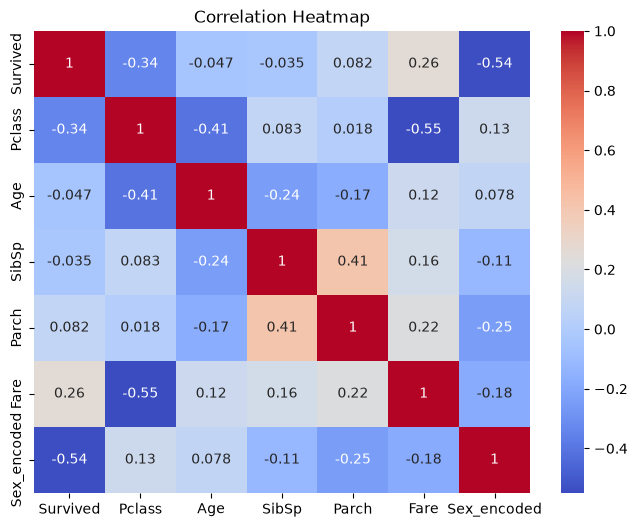

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric_cols = ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex_encoded']
plt.figure(figsize=(8,6))
sns.heatmap(titanic[numeric_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [9]:
from sklearn.feature_selection import SelectKBest, f_classif

X = titanic[numeric_cols].drop(columns=['Survived'])
y = titanic['Survived']

selector = SelectKBest(score_func=f_classif, k=3)
selector.fit(X, y)

scores = pd.DataFrame({'Feature': X.columns, 'Score': selector.scores_})
print(scores.sort_values('Score', ascending=False))

       Feature       Score
5  Sex_encoded  372.405724
0       Pclass  115.031272
4         Fare   63.030764
3        Parch    5.963464
1          Age    1.989578
2        SibSp    1.110572


In [10]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# All features
X_all = titanic[['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex_encoded']]
X_top3 = titanic[['Sex_encoded', 'Pclass', 'Fare']]
y = titanic['Survived']

X_all_train, X_all_test, y_train, y_test = train_test_split(X_all, y, test_size=0.2, random_state=42)
X_top3_train, X_top3_test, _, _ = train_test_split(X_top3, y, test_size=0.2, random_state=42)

model_all = LogisticRegression(max_iter=1000).fit(X_all_train, y_train)
model_top3 = LogisticRegression(max_iter=1000).fit(X_top3_train, y_train)

acc_all = accuracy_score(y_test, model_all.predict(X_all_test))
acc_top3 = accuracy_score(y_test, model_top3.predict(X_top3_test))

print("Accuracy with all features:", acc_all)
print("Accuracy with top 3 features:", acc_top3)

Accuracy with all features: 0.8268156424581006
Accuracy with top 3 features: 0.7821229050279329


Sex_encoded, Pclass, and Fare scored highest individually but using obly those 3 features resulted in lower accuracy as compared to using all 6 features.This is because SelectKBest 
scores each feature in isolation and doesn't account for how features work together. This suggests that its worth keeping all these features

In [11]:
X = titanic[['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex_encoded']]
y = titanic['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Original Survived ratio:\n", y.value_counts(normalize=True))
print("\nTrain Survived ratio:\n", y_train.value_counts(normalize=True))
print("\nTest Survived ratio:\n", y_test.value_counts(normalize=True))

Original Survived ratio:
 Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64

Train Survived ratio:
 Survived
0    0.616573
1    0.383427
Name: proportion, dtype: float64

Test Survived ratio:
 Survived
0    0.614525
1    0.385475
Name: proportion, dtype: float64
